In [1]:
import torch

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model_v2_compatible import SeqNN

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1127400/ipykernel_1754041/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("/scratch1/smaruj/genomic_insertion_loci/fold1_selected_genomic_windows_centered.tsv", sep="\t")
# df = df.drop_duplicates(subset=["chrom", "centered_start", "centered_end"])

In [7]:
boundary_mask_path = "/scratch1/smaruj/genomic_insertion_loci/boundary_indices.pt"

In [8]:
import sys
sys.path.insert(0, "/home1/smaruj/ledidi")
from ledidi import Ledidi

In [9]:
bin_size = 2048
cropping_applied = 64
padding_bins = 2
padding = padding_bins * bin_size

slice_0_bins = [256]
slice_0_start = (min(slice_0_bins) + cropping_applied - padding_bins) * bin_size
slice_0_end = (max(slice_0_bins) + 1 + cropping_applied + padding_bins) * bin_size

In [10]:
for row in df[5:6].itertuples(index=False):
    chrom, pred_start, pred_end = row.chrom, row.centered_start, row.centered_end
    
    print(f"Boundary generation for genome location: {chrom}:{pred_start}-{pred_end}")
    
    X = torch.load(f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold1/{chrom}_{pred_start}_{pred_end}_X.pt", weights_only=True, map_location=device)
    target = torch.load(f"/scratch1/smaruj/genomic_insertion_loci/targets_-0.5/fold1/{chrom}_{pred_start}_{pred_end}_target.pt", weights_only=True, map_location=device)
    tower_output_path = f"/scratch1/smaruj/genomic_insertion_loci/tower_outputs/fold1/{chrom}_{pred_start}_{pred_end}_tower_out.pt"
    
    wrapper = Ledidi(model, 
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),
                 batch_size=1,
                 max_iter=3000,
                 early_stopping_iter=2000,
                 return_history=True,
                 verbose=True,
                 bin_size=2048,
                 input_mask_slices_0=[256], # mid-bin
                 cropping_applied=64,
                 output_mask_path=boundary_mask_path,
                 use_semifreddo=True,
                 semifreddo_temp_output_path=tower_output_path,
                 punish_ctcf=False,
                 ctcf_meme_path=None
                 ).cuda()
    
    slice_0_torch = X[:, :, slice_0_start:slice_0_end]
    
    x_bar_slice_0, history = wrapper.fit_transform(X=slice_0_torch, y_bar=target)
    
    
    # torch.save(x_bar_slice_0[:,:,padding:-padding], f"/scratch1/smaruj/genomic_insertion_loci/results/{chrom}_{pred_start}_{pred_end}_slice.pt")
    

Boundary generation for genome location: chr1:68870144-70180864
Model in train mode: False
Gradients enabled for weights - slice 0: True
Weights shape - slice 0: torch.Size([1, 4, 2048])
Local loss applied.
iter=I	input_loss=0.0	output_loss=3.276e+04	total_loss=3.276e+04	time=0.0
iter=100	input_loss=575.0	output_loss=2.674e+04	total_loss=2.68e+04	time=5.473
iter=200	input_loss=684.0	output_loss=2.496e+04	total_loss=2.503e+04	time=5.37
iter=300	input_loss=686.0	output_loss=2.463e+04	total_loss=2.47e+04	time=5.378
iter=400	input_loss=722.0	output_loss=2.44e+04	total_loss=2.447e+04	time=5.372
iter=500	input_loss=758.0	output_loss=2.431e+04	total_loss=2.438e+04	time=5.389
iter=600	input_loss=781.0	output_loss=2.425e+04	total_loss=2.433e+04	time=5.376
iter=700	input_loss=765.0	output_loss=2.428e+04	total_loss=2.435e+04	time=5.369
iter=800	input_loss=752.0	output_loss=2.427e+04	total_loss=2.434e+04	time=5.368
iter=900	input_loss=766.0	output_loss=2.425e+04	total_loss=2.433e+04	time=5.383
ite

In [11]:
for key in history:
    print(key)

input_loss
output_loss
total_loss
gc_content
batch_size
edit_positions


In [12]:
edit_positions = history["edit_positions"][:2807]

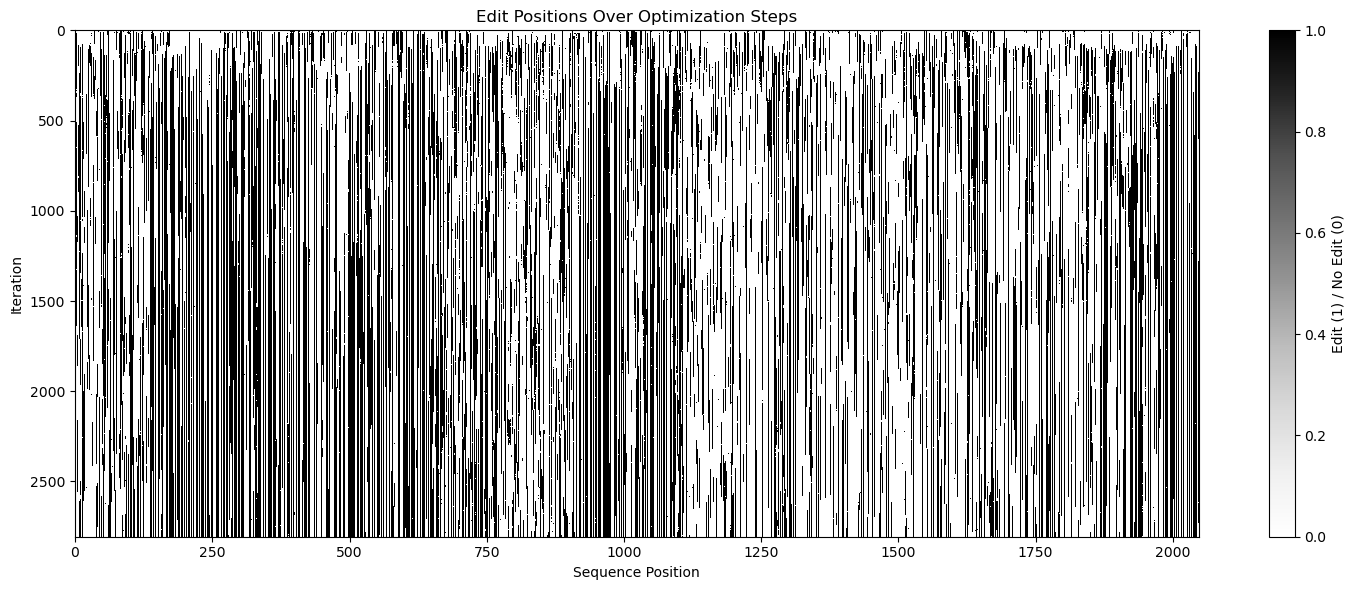

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Convert your list of 2763 lists (each of length 2048) to a 2D array
edit_array = np.array(edit_positions)  # shape: (2763, 2048)

plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect='auto', cmap='Greys', interpolation='none')

plt.xlabel('Sequence Position')
plt.ylabel('Iteration')
plt.title('Edit Positions Over Optimization Steps')
plt.colorbar(label='Edit (1) / No Edit (0)')

plt.tight_layout()
plt.show()

In [15]:
from pyfaidx import Fasta

In [16]:
fasta_file = "/project/fudenber_735/genomes/mm10/mm10.fa"
genome = Fasta(fasta_file)

In [17]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [18]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [19]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [20]:
from tangermeme.tools import fimo

In [21]:
hits = fimo.fimo(
    motifs=motifs_dict,
    sequences=x_bar_slice_0[:, :, 4096:-4096],
    threshold=1e-4,
    reverse_complement=True
)[0]

In [22]:
hits

,motif_name,motif_idx,sequence_name,start,end,strand,score,p-value
0,CTCF,0,0,368,387,+,9.058691,7.629793e-05
1,CTCF,0,0,937,956,+,20.318420,8.505958e-08
2,CTCF,0,0,985,1004,+,15.998275,2.109889e-06
3,CTCF,0,0,1909,1928,+,13.992359,6.834227e-06
4,CTCF,0,0,1996,2015,+,18.384605,4.184731e-07
5,CTCF,0,0,1051,1070,-,12.025198,1.866844e-05
6,CTCF,0,0,1907,1926,-,9.164144,7.302562e-05


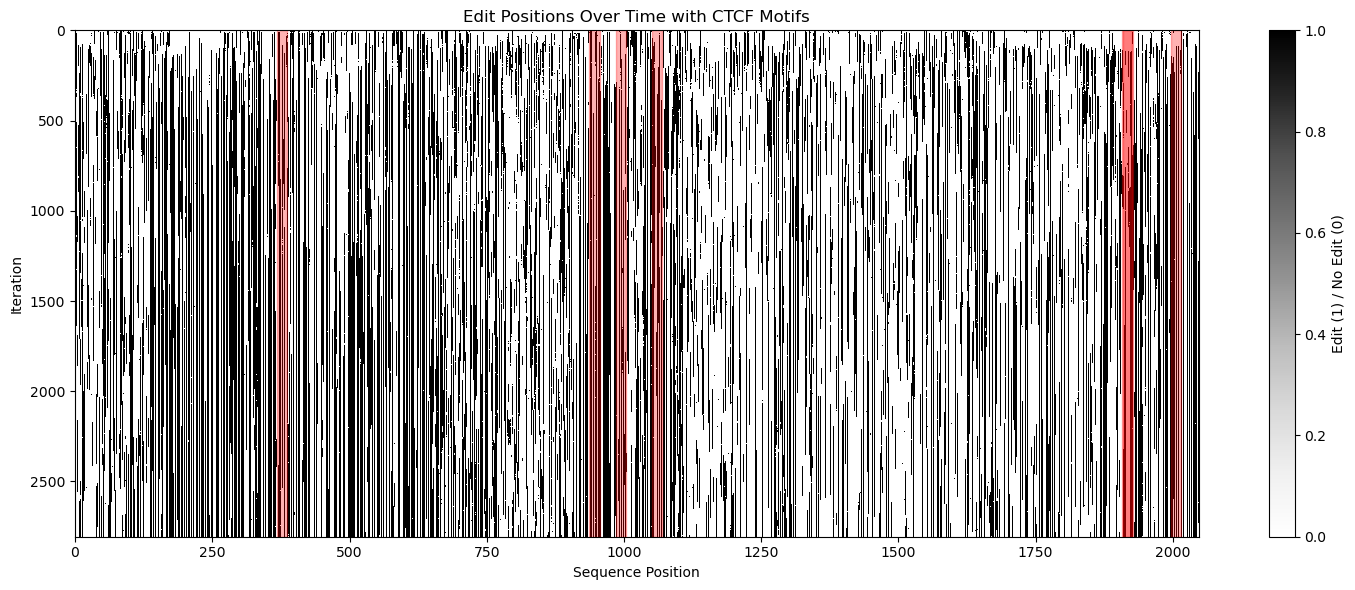

In [23]:
edit_array = np.array(edit_positions)  # shape: (2763, 2048)

plt.figure(figsize=(15, 6))
plt.imshow(edit_array, aspect='auto', cmap='Greys', interpolation='none')

# Plot vertical shaded regions for CTCF motif positions
for _, row in hits.iterrows():
    start = row['start']
    end = row['end']
    plt.axvspan(start, end, color='red', alpha=0.3)

plt.xlabel('Sequence Position')
plt.ylabel('Iteration')
plt.title('Edit Positions Over Time with CTCF Motifs')
plt.colorbar(label='Edit (1) / No Edit (0)')

plt.tight_layout()
plt.show()